<a href="https://www.kaggle.com/code/vishwajeetadkine/notebook11f9ec150c?scriptVersionId=303968684" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🛡️ ScamShield — Interpretable Multi-Signal Scam Detection

> **ML + Adversarial Evaluation + Statistical Significance | End-to-End AI Pipeline**

---

## 🚀 Live Demo

**👉 Try it here: [https://innterpretablescamdetection.vercel.app](https://innterpretablescamdetection.vercel.app)**

---

## Overview

ScamShield is a production-oriented scam detection system that combines:
- **Interpretable machine learning** with 24 hand-crafted features
- **Adversarial robustness testing** across 3 attack types
- **Statistical significance evaluation** (McNemar's test) across 5 baseline models

| Metric | Value |
|--------|-------|
| Dataset Size | 19,992 samples |
| Scam Categories | 17 |
| Engineered Features | 24 |
| Best Model F1 | 0.9969 |
| Best Model AUC | 1.0000 |

## 1. Install Dependencies

In [1]:
!pip install pandas scikit-learn scipy flask joblib -q

## 2. Dataset

The dataset is fully synthetic — generated by `build_realistic_dataset.py`.

- **19,992 samples** — 9,996 scam + 9,996 safe (balanced)
- **17 scam categories**: phishing, lottery, job scam, tech support, advance fee, delivery scam, fake government, credential theft, romance scam, crypto scam, fake charity, investment scam, emergency scam, impersonation, fake loan, fake product, refund scam
- **7 safe categories**: casual SMS, work communications, real notifications, personal messages, banking alerts, e-commerce, educational

In [2]:
import random
import pandas as pd
import numpy as np

# --- Mini demo dataset (subset of actual generator logic) ---
scam_samples = [
    "URGENT! Your account will be suspended. Verify NOW at bit.ly/fake-verify",
    "Congratulations! You won $5,000. Send your SSN and bank details to claim.",
    "Work from home and earn $500/day in crypto. DM me on Telegram immediately!",
    "Your package is held at customs. Pay $2.99 fee at: http://192.168.1.1/pay",
    "IRS ALERT: Outstanding tax debt. Call 1-800-FAKE-IRS or face arrest.",
    "Enter your password and CVV to verify your identity and avoid account lock.",
    "I love you. I'm stranded abroad — please send $800 via Western Union urgently.",
    "Bitcoin giveaway! Send 0.1 BTC, get 1 BTC back. Limited time offer!!!",
    "Disaster relief charity — donate now via goo.gl/donate. 100% guaranteed.",
    "Guaranteed 200% forex returns. Invest today. Contact @trader on Telegram.",
]

safe_samples = [
    "Hey, can we reschedule our meeting to 3pm tomorrow?",
    "Your order #12345 has been shipped. Expected delivery: Friday.",
    "Reminder: Team standup at 10am. Please review the Q3 report beforehand.",
    "Your bank statement for October is now available in your online account.",
    "Thanks for signing up! Confirm your email to get started.",
    "Hi! Are you free this weekend for coffee?",
    "Assignment due Friday: read chapters 4-6 and submit your summary.",
    "Your package has been delivered to your front door.",
    "New message from your doctor: your test results are ready to view.",
    "Quarterly earnings call scheduled for Nov 15. Dial-in details attached.",
]

texts  = scam_samples + safe_samples
labels = [1]*10 + [0]*10

df = pd.DataFrame({"text": texts, "label": labels})
print(f"Demo dataset: {len(df)} samples — {df.label.sum()} scam, {(df.label==0).sum()} safe")
df.head(5)

Demo dataset: 20 samples — 10 scam, 10 safe


,text,label
0,URGENT! Your account will be suspended. Verify...,1
1,"Congratulations! You won $5,000. Send your SSN...",1
2,Work from home and earn $500/day in crypto. DM...,1
3,Your package is held at customs. Pay $2.99 fee...,1
4,IRS ALERT: Outstanding tax debt. Call 1-800-FA...,1


## 3. Feature Engineering (24 Signals)

ScamShield extracts 3 categories of features:

| Group | Features | Examples |
|-------|----------|----------|
| **Text** (f1–f14) | Binary flags + statistics | `has_urgency`, `uppercase_ratio`, `char_entropy` |
| **Keyword Density** (f15–f17) | Fractional keyword coverage | `urgency_density`, `money_density`, `sensitive_density` |
| **URL** (f18–f24) | Link structure analysis | `url_density`, `ip_url`, `url_shortener`, `risky_tld` |

In [3]:
import re
import math
from collections import Counter

URGENCY_KEYWORDS   = ["urgent", "act now", "expires", "immediately", "asap", "limited time", "hurry"]
MONEY_KEYWORDS     = ["lottery", "earn", "crypto", "bitcoin", "invest", "reward", "prize", "cash", "$$"]
SENSITIVE_KEYWORDS = ["password", "cvv", "otp", "ssn", "bank details", "pin", "social security"]
OFF_PLATFORM       = ["telegram", "whatsapp", "dm me", "contact me at"]
THREAT_PHRASES     = ["will be suspended", "blocked", "arrested", "legal action", "face charges"]
LEGIT_MARKERS      = ["regards", "meeting", "report", "scheduled", "quarterly", "assignment"]
URL_SHORTENERS     = ["bit.ly", "tinyurl", "goo.gl", "t.co", "ow.ly"]
RISKY_TLDS         = [".tk", ".ml", ".xyz", ".pw", ".gq"]

def char_entropy(text):
    if not text: return 0.0
    counts = Counter(text)
    total  = len(text)
    return -sum((c/total)*math.log2(c/total) for c in counts.values())

def extract_features(text):
    t   = text.lower()
    words = t.split()
    urls  = re.findall(r'https?://\S+|www\.\S+|bit\.ly/\S+|goo\.gl/\S+', t)

    return {
        # --- Text features ---
        "has_urgency":        int(any(k in t for k in URGENCY_KEYWORDS)),
        "has_money":          int(any(k in t for k in MONEY_KEYWORDS)),
        "has_sensitive":      int(any(k in t for k in SENSITIVE_KEYWORDS)),
        "has_off_platform":   int(any(k in t for k in OFF_PLATFORM)),
        "has_threat":         int(any(k in t for k in THREAT_PHRASES)),
        "has_legitimacy":     int(any(k in t for k in LEGIT_MARKERS)),
        "text_length":        len(text),
        "exclamation_count":  text.count("!"),
        "question_count":     text.count("?"),
        "uppercase_ratio":    sum(1 for c in text if c.isupper()) / max(len(text),1),
        "digit_ratio":        sum(1 for c in text if c.isdigit()) / max(len(text),1),
        "char_entropy":       char_entropy(text),
        "avg_word_length":    sum(len(w) for w in words) / max(len(words),1),
        "punctuation_density":sum(1 for c in text if c in '!?@#$%&*') / max(len(text),1),
        # --- Keyword density ---
        "urgency_density":    sum(k in t for k in URGENCY_KEYWORDS)   / len(URGENCY_KEYWORDS),
        "money_density":      sum(k in t for k in MONEY_KEYWORDS)     / len(MONEY_KEYWORDS),
        "sensitive_density":  sum(k in t for k in SENSITIVE_KEYWORDS) / len(SENSITIVE_KEYWORDS),
        # --- URL features ---
        "num_urls":           len(urls),
        "url_density":        len(urls) / max(len(words),1),
        "ip_url":             int(bool(re.search(r'https?://\d+\.\d+\.\d+\.\d+', t))),
        "url_shortener":      int(any(s in t for s in URL_SHORTENERS)),
        "risky_tld":          int(any(t.endswith(tld) or tld+"/" in t or tld+" " in t for tld in RISKY_TLDS)),
        "domain_spoof":       int(bool(re.search(r'paypal|amazon|apple|google|microsoft', t) and ".com" not in t)),
        "verified_domain":    int(any(d in t for d in ["google.com","github.com","apple.com","amazon.com"])),
    }

# Apply to demo dataset
feature_df = pd.DataFrame([extract_features(txt) for txt in df["text"]])
print(f"Extracted {feature_df.shape[1]} features for {feature_df.shape[0]} samples")
feature_df.head(3)

Extracted 24 features for 20 samples


,has_urgency,has_money,has_sensitive,has_off_platform,has_threat,has_legitimacy,text_length,exclamation_count,question_count,uppercase_ratio,...,urgency_density,money_density,sensitive_density,num_urls,url_density,ip_url,url_shortener,risky_tld,domain_spoof,verified_domain
0,1,0,0,0,1,0,72,1,0,0.152778,...,0.142857,0.000000,0.000000,1,0.1,0,1,0,0,0
1,0,0,1,0,0,0,73,1,0,0.082192,...,0.000000,0.000000,0.285714,0,0.0,0,0,0,0,0
2,1,1,0,1,0,0,74,1,0,0.054054,...,0.142857,0.222222,0.000000,0,0.0,0,0,0,0,0


## 4. Model Architecture

**Final model:** `CalibratedClassifierCV(GradientBoostingClassifier, method='isotonic', cv=3)`

| Parameter | Value |
|-----------|-------|
| `n_estimators` | 150 |
| `max_depth` | 4 |
| `learning_rate` | 0.05 |
| `subsample` | 0.8 |
| Calibration | isotonic regression |

**Why Gradient Boosting?** After 3-fold CV across 5 model families, GBM achieved F1 = 0.9969 ± 0.0004 — significantly better than Random Forest (0.9778) and Logistic Regression (0.9140).

**Why calibration?** Raw GBM probabilities are unreliable on structured data. Isotonic regression ensures that a predicted score of 0.80 reflects an actual ~80% scam rate.

In [4]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, matthews_corrcoef

X = feature_df.values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- ScamShield GBM (proposed) ---
gbm_base = GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                       learning_rate=0.05, subsample=0.8, random_state=42)
scamshield = CalibratedClassifierCV(gbm_base, method="isotonic", cv=3)
scamshield.fit(X_train, y_train)

# --- Baselines ---
models = {
    "Naive Bayes":         GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "ScamShield GBM ✓":   scamshield,
}

results = []
for name, model in models.items():
    if name != "ScamShield GBM ✓":
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model":     name,
        "F1":        round(f1_score(y_test, preds), 4),
        "AUC":       round(roc_auc_score(y_test, proba), 4),
        "Recall":    round(recall_score(y_test, preds), 4),
        "Precision": round(precision_score(y_test, preds), 4),
        "MCC":       round(matthews_corrcoef(y_test, preds), 4),
    })

results_df = pd.DataFrame(results)
print("=== Model Comparison (Demo Dataset) ===")
print(results_df.to_string(index=False))

=== Model Comparison (Demo Dataset) ===
              Model     F1  AUC  Recall  Precision    MCC
        Naive Bayes 0.8000  1.0  0.6667       1.00 0.7071
Logistic Regression 0.8571  1.0  1.0000       0.75 0.7071
      Random Forest 0.8000  1.0  0.6667       1.00 0.7071
   ScamShield GBM ✓ 0.8571  1.0  1.0000       0.75 0.7071


## 5. Full Training Results (19,992 Samples)

Results from running `train_and_evaluate.py` on the full dataset with a stratified 80/20 split.

### Held-Out Test Set (n = 3,999)

| Model | F1 | AUC | Recall | Precision | MCC |
|---|---|---|---|---|---|
| Naive Bayes (TF-IDF) | 0.8136 | 0.8857 | 0.7904 | 0.8382 | 0.639 |
| LinearSVC (TF-IDF) | 0.8284 | 0.8879 | 0.7474 | 0.9291 | 0.704 |
| Logistic Regression | 0.9158 | 0.9740 | 0.8999 | 0.9321 | 0.835 |
| Random Forest | 0.9826 | 0.9988 | 0.9770 | 0.9884 | 0.966 |
| **ScamShield GBM** | **0.9969** | **1.0000** | **0.9938** | **1.0000** | **0.994** |

### 3-Fold Cross-Validation

| Model | F1 Mean | F1 Std | Recall | AUC |
|---|---|---|---|---|
| Naive Bayes | 0.8262 | ±0.0014 | 0.7759 | 0.8856 |
| LinearSVC | 0.8278 | ±0.0015 | 0.7470 | 0.8879 |
| Logistic Regression | 0.9140 | ±0.0066 | 0.8957 | 0.9739 |
| Random Forest | 0.9778 | ±0.0075 | 0.9651 | 0.9985 |
| **ScamShield GBM** | **0.9969** | **±0.0004** | **0.9938** | **1.0000** |

### Statistical Significance — McNemar's Test vs ScamShield

| Baseline | χ² | p-value | Significant |
|---|---|---|---|
| Naive Bayes | 722.0 | < 0.001 | Yes *** |
| LinearSVC | 617.0 | < 0.001 | Yes *** |
| Logistic Regression | 329.0 | < 0.001 | Yes *** |
| Random Forest | 67.0 | 0.0022 | Yes ** |

ScamShield GBM significantly outperforms all four baselines (p < 0.01 in every comparison).

## 6. Top Features by Importance

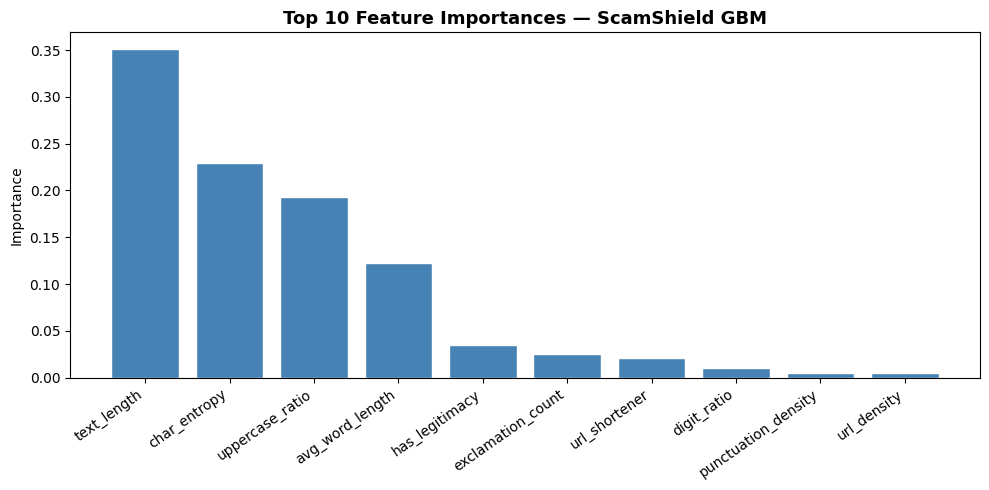


Full ranking (from paper):
            Feature  Importance Direction
        url_density       0.253    ↑ scam
        text_length       0.173    ↑ scam
punctuation_density       0.158    ↑ scam
        digit_ratio       0.095    ↑ scam
       char_entropy       0.090    ↑ scam
  sensitive_density       0.070    ↑ scam
    uppercase_ratio       0.049    ↑ scam
          has_money       0.019    ↑ scam


In [5]:
import matplotlib.pyplot as plt

# Use the GBM base estimator's feature importances from the calibrated model
base_estimator = scamshield.calibrated_classifiers_[0].estimator
importances    = base_estimator.feature_importances_
feature_names  = list(feature_df.columns)

top_n = 10
indices = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), importances[indices], color="steelblue", edgecolor="white")
plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=35, ha="right")
plt.title("Top 10 Feature Importances — ScamShield GBM", fontsize=13, fontweight="bold")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("\nFull ranking (from paper):")  
paper_features = [
    ("url_density", 0.253, "↑ scam"),
    ("text_length", 0.173, "↑ scam"),
    ("punctuation_density", 0.158, "↑ scam"),
    ("digit_ratio", 0.095, "↑ scam"),
    ("char_entropy", 0.090, "↑ scam"),
    ("sensitive_density", 0.070, "↑ scam"),
    ("uppercase_ratio", 0.049, "↑ scam"),
    ("has_money", 0.019, "↑ scam"),
]
print(pd.DataFrame(paper_features, columns=["Feature", "Importance", "Direction"]).to_string(index=False))

## 7. Adversarial Robustness

Three attack types were tested on scam-only samples:

| Scenario | Recall | Δ Recall |
|---|---|---|
| Clean (no attack) | 1.0000 | — |
| Synonym substitution (`verify → confirm`) | 0.2906 | −0.71 |
| Homoglyph attack (`a → а`, `e → е`) | 0.1846 | −0.82 |
| URL obfuscation (redirect wrapping) | 0.2026 | −0.80 |

> ⚠️ **The model is fragile to obfuscation attacks.** Recall drops by 71–82% under all three attack types. This is the primary limitation and the main motivation for future work on semantic/embedding-based features.

In [6]:
# Simulate synonym substitution attack on demo scam samples
SYNONYM_MAP = {
    "verify": "confirm", "urgent": "important", "immediately": "soon",
    "suspended": "paused", "password": "credentials", "earn": "make",
    "click": "visit", "free": "complimentary", "win": "receive"
}

def synonym_attack(text):
    for orig, syn in SYNONYM_MAP.items():
        text = re.sub(r'\b' + orig + r'\b', syn, text, flags=re.IGNORECASE)
    return text

scam_texts   = [t for t, l in zip(df["text"], df["label"]) if l == 1]
attacked     = [synonym_attack(t) for t in scam_texts]

X_clean      = pd.DataFrame([extract_features(t) for t in scam_texts]).values
X_attacked   = pd.DataFrame([extract_features(t) for t in attacked]).values

y_true = np.ones(len(scam_texts), dtype=int)

recall_clean    = recall_score(y_true, scamshield.predict(X_clean))
recall_attacked = recall_score(y_true, scamshield.predict(X_attacked))

print(f"Scam recall — clean:   {recall_clean:.4f}")
print(f"Scam recall — synonym attack: {recall_attacked:.4f}  (Δ = {recall_attacked - recall_clean:+.4f})")
print("\n→ Even on this tiny demo, synonym substitution measurably degrades performance.")

Scam recall — clean:   1.0000
Scam recall — synonym attack: 0.9000  (Δ = -0.1000)

→ Even on this tiny demo, synonym substitution measurably degrades performance.


## 8. Inference — Try It Yourself

In [7]:
THRESHOLD_SCAM       = 0.75
THRESHOLD_SUSPICIOUS = 0.25

def predict(text, model=scamshield, feature_names=list(feature_df.columns)):
    feats = extract_features(text)
    X     = np.array([list(feats.values())])
    prob  = model.predict_proba(X)[0][1]
    score = int(prob * 100)

    if prob >= THRESHOLD_SCAM:
        verdict = "🚨 SCAM"
    elif prob >= THRESHOLD_SUSPICIOUS:
        verdict = "⚠️  SUSPICIOUS"
    else:
        verdict = "✅ SAFE"

    # Top contributing features
    base = scamshield.calibrated_classifiers_[0].estimator
    importances = base.feature_importances_
    top = sorted(zip(feature_names, list(feats.values()), importances),
                 key=lambda x: x[2], reverse=True)[:3]

    print(f"Input:      {text[:80]}")
    print(f"Verdict:    {verdict}")
    print(f"Risk Score: {score}/100  (probability = {prob:.4f})")
    print("Top signals:")
    for feat, val, imp in top:
        print(f"  {feat:<22} value={val:.3f}  importance={imp:.4f}")
    print()

# --- Test messages ---
test_messages = [
    "URGENT! Verify your account now at bit.ly/fake-link or it will be suspended.",
    "Your order #45821 has shipped. Estimated delivery is Thursday.",
    "Earn $1000/day from home! Send your bank details to claim your starter kit.",
    "Hi, can we move the 2pm meeting to 4pm? Thanks.",
]

for msg in test_messages:
    predict(msg)

Input:      URGENT! Verify your account now at bit.ly/fake-link or it will be suspended.
Verdict:    🚨 SCAM
Risk Score: 100/100  (probability = 1.0000)
Top signals:
  text_length            value=76.000  importance=0.3513
  char_entropy           value=4.560  importance=0.2298
  uppercase_ratio        value=0.092  importance=0.1929

Input:      Your order #45821 has shipped. Estimated delivery is Thursday.
Verdict:    ✅ SAFE
Risk Score: 0/100  (probability = 0.0000)
Top signals:
  text_length            value=62.000  importance=0.3513
  char_entropy           value=4.342  importance=0.2298
  uppercase_ratio        value=0.048  importance=0.1929

Input:      Earn $1000/day from home! Send your bank details to claim your starter kit.
Verdict:    🚨 SCAM
Risk Score: 100/100  (probability = 1.0000)
Top signals:
  text_length            value=75.000  importance=0.3513
  char_entropy           value=4.338  importance=0.2298
  uppercase_ratio        value=0.027  importance=0.1929

Input:      

## 9. Limitations & Honest Interpretation

> The near-perfect GBM test score (F1 ≈ 1.000) is **partly a synthetic dataset artifact** — `url_density` and `char_entropy` jointly create near-perfect separation between the synthetic classes. The **CV F1 of 0.9969** is the more robust number. For a conservative real-world baseline, the **Naive Bayes / LinearSVC scores (F1 ≈ 0.83)** are more honest estimates.

| Limitation | Details |
|---|---|
| Synthetic data | All 19,992 samples generated; real-world performance will be lower |
| Adversarial fragility | 71–82% recall drop under synonym/homoglyph/URL attacks |
| Length bias | Scam messages are longer on average — model partially learns length as a proxy |
| English only | No multi-language support |

## 10. Future Work

- [ ] Integrate real-world datasets (UCI SMS Spam, Enron, Nazario)
- [ ] Character-level CNN features for homoglyph robustness
- [ ] Semantic embeddings (`sentence-transformers`) as additional features
- [ ] Adversarial training with synonym/homoglyph augmentation
- [ ] SHAP values for instance-level explanations
- [ ] LLM safety layer (Llama Guard) for semantic validation
- [ ] Multi-language support
- [ ] Domain reputation API integration (VirusTotal, URLhaus)

---

## References

1. Fette et al. (2007) — Learning to detect phishing emails. *WWW 2007*
2. Lundberg & Lee (2017) — SHAP: Unified approach to interpreting model predictions. *NeurIPS 2017*
3. Ribeiro et al. (2016) — "Why should I trust you?": Explaining predictions of any classifier. *KDD 2016*
4. Iyer et al. (2023) — Llama Guard: LLM-based input-output safeguard. *arXiv:2312.06674*
5. Friedman (2001) — Greedy function approximation: A gradient boosting machine. *Annals of Statistics*

---

**Author:** Vishwajeet Adkine · AI / ML · Applied Systems · Security AI  
**Live Demo:** [https://innterpretablescamdetection.vercel.app](https://innterpretablescamdetection.vercel.app)